# 第三部分 3.1：神经网络基础

| 章节 | 内容 |
|------|------|
| **3.1 神经网络基础** | 感知机、多层网络、激活函数 |
| **3.2 训练原理** | 前向传播、反向传播、梯度下降变体（SGD / Adam）|
| **3.3 正则化与调参** | Dropout、BatchNorm、学习率调度、早停 |

---

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

matplotlib.rcParams['font.family'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
print('环境就绪，PyTorch 版本：', torch.__version__)

环境就绪，PyTorch 版本： 2.12.0+cpu


## 3.1 神经网络基础

### 感知机（Perceptron）

**感知机**是 1957 年 Rosenblatt 提出的最早的人工神经网络模型，灵感来自生物神经元。它的结构很简单：

$$z = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \mathbf{w}^\top \mathbf{x} + b$$

$$\hat{y} = \begin{cases} 1 & \text{if } z \geq 0 \\ 0 & \text{if } z < 0 \end{cases}$$

激活函数是**阶跃函数（Step Function）**，输出只有 **0 或 1**，只能做**二分类**。

感知机的训练规则也很简单：预测正确则不更新，预测错误则把权重向正确方向推一步（感知机学习算法）。不需要损失函数，也不需要梯度下降。

**感知机的根本局限**：
- 决策边界是一条直线（线性超平面），只能处理**线性可分**问题
- 对于 XOR 这类最简单的非线性问题，无论怎么调权重都无法正确分类
- 1969 年 Minsky 和 Papert 从数学上证明了这一点，直接导致第一次「AI 寒冬」

---

### 从感知机到现代神经元

感知机的阶跃函数有两个致命问题：
1. **不可微**：无法用梯度下降训练，必须用那套简单但局限的感知机学习算法
2. **输出非连续**：0/1 输出之间没有「置信度」，无法表达「我有 80% 把握」

解决方案：把阶跃函数**替换为可微的连续激活函数**，让输出从离散的 0/1 变成连续值。这样的单元通常叫**神经元（Neuron）**，是现代深度学习的基本单元：

$$z = \mathbf{w}^\top \mathbf{x} + b$$

$$\hat{y} = f(z)$$

其中 $f$ 是**激活函数**，可以是 Sigmoid、ReLU 等任意可微函数。现在可以对损失函数求导，用梯度下降训练了。

> 感知机 → 神经元：结构完全相同，区别只在激活函数。感知机是神经元的历史原型，但两者的训练方式和能力不同。
>
> 顺便提一下：用 Sigmoid 激活 + 交叉熵损失训练的单个神经元，就等价于**逻辑回归**。

---

### 激活函数

激活函数的作用：给网络引入非线性，使其能拟合任意复杂函数。

| 激活函数 | 公式 | 输出范围 | 主要特点 |
|---------|------|---------|----------|
| **Sigmoid** | $\frac{1}{1+e^{-z}}$ | (0, 1) | 输出可解释为概率；缺点：梯度饱和、梯度消失 |
| **Tanh** | $\frac{e^z - e^{-z}}{e^z + e^{-z}}$ | (-1, 1) | 零中心化，比 Sigmoid 收敛快；仍有梯度饱和 |
| **ReLU** | $\max(0, z)$ | [0, +∞) | 计算极快；正区间无梯度饱和；负区间梯度为 0（Dead ReLU 问题）|
| **Leaky ReLU** | $\max(0.01z, z)$ | (-∞, +∞) | 修复 Dead ReLU，负区间有小梯度 |
| **GELU** | $z \cdot \Phi(z)$ | 近似 ReLU | Transformer 常用，平滑版 ReLU |

**实践建议**：
- 隐藏层：优先用 **ReLU**（默认）或 Leaky ReLU
- 输出层：分类用 Sigmoid（二分类）/ Softmax（多分类），回归不加激活函数
- Sigmoid / Tanh 只在特定场合使用（如 RNN 的门控单元）

---

### 梯度饱和（Gradient Saturation）

Sigmoid 在 $|z|$ 很大时，导数趋近于 0——对应图中曲线在两端变得很平。在反向传播中，梯度通过链式法则逐层相乘，如果每层的梯度都很小（< 1），多层相乘后梯度指数级衰减，**深层网络的权重几乎得不到更新**，这就是**梯度消失问题（Vanishing Gradient）**。

ReLU 的解决方式：正区间导数恒为 1，梯度不衰减（但负区间导数为 0，造成 Dead ReLU）。

---

### 多层全连接神经网络

但即使换成可微激活函数，**单个神经元仍然只能学线性边界**——只要是单层结构，决策边界就是直线。

**解决方案**：堆叠多层神经元，在输入层和输出层之间加入**隐藏层（Hidden Layer）**。

```
输入层 → 隐藏层 1 → 隐藏层 2 → ... → 输出层
(特征)    (变换)      (变换)           (预测)
```

**为什么隐藏层有效？**

每一层都在学习数据的一种**表示（Representation）**：
- 第 1 层：学习原始特征的组合（边、纹理）
- 第 2 层：组合低层特征构成更抽象的概念
- 越深的层：越高级的语义抽象

**关键认知**：如果只是线性层堆叠而没有激活函数，多层等价于一层（线性变换的复合仍是线性变换）。**激活函数引入非线性是深度学习有效的根本原因。**

### 深入理解：XOR 问题

XOR（异或）是理解"为什么需要隐藏层"最经典的例子。

**XOR 真值表**

| x₁ | x₂ | 输出 |
|----|----|------|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

把这 4 个点画在坐标轴上：

```
x₂
1 |  ×(0,1)    ○(1,1)
  |
0 |  ○(0,0)    ×(1,0)
  |___________________
       0         1    x₁

× = 输出1，○ = 输出0
```

**为什么单层神经元解决不了**

单个神经元的决策边界是 `w₁x₁ + w₂x₂ + b = 0`，在二维平面上永远是一条直线。你可以旋转它、平移它，但无法让它弯曲。

观察上图中 4 个点的分布：× 在左上和右下，○ 在左下和右上，呈对角交叉排列。无论你怎么画一条直线，都必然把某个点划到错误的一侧——这不是训练不够的问题，是数学上就不存在这样的直线。

**隐藏层如何解决：两步走**

加入 2 个隐藏神经元，每个神经元各学一条线：

- **神经元 h₁**：学会判断"x₁ + x₂ 是否 > 0.5"，即至少有一个输入为 1
- **神经元 h₂**：学会判断"x₁ + x₂ 是否 > 1.5"，即两个输入同时为 1

经过隐藏层变换后，4 个原始点被映射到了新坐标系 (h₁, h₂) 中：

| 原始点 | h₁（至少一个1？） | h₂（两个都是1？） | 标签 |
|--------|-----------------|-----------------|------|
| (0, 0) | 0 | 0 | 0 |
| (0, 1) | 1 | 0 | 1 |
| (1, 0) | 1 | 0 | 1 |
| (1, 1) | 1 | 1 | 0 |

注意 (0,1) 和 (1,0) 在新空间里**坐标完全相同**，都是 (1, 0)——原本分散在对角的两个点，被折叠到了同一位置。

在新空间里，○ 在 (0,0) 和 (1,1)，× 在 (1,0)。现在一条直线就能分开了。

**核心直觉：隐藏层在"折叠空间"**

隐藏层并不是简单地把数据放到更高维度，而是**重新排列了数据点之间的相对位置**。原本在原始空间里线性不可分的数据，经过变换后在新空间里变成了线性可分的。输出层做的只是在这个新空间里画一条分界线。

层数越多，就能做越多次折叠，处理越复杂的形状。

=== 单层神经元 vs XOR ===


单层神经元预测结果（训练 5000 轮）：
  x=[0. 0.]  真实=0  预测概率=0.500  预测=0  ✓
  x=[0. 1.]  真实=1  预测概率=0.500  预测=0  ✗
  x=[1. 0.]  真实=1  预测概率=0.500  预测=0  ✗
  x=[1. 1.]  真实=0  预测概率=0.500  预测=0  ✓
  准确率：50%  → 无论训练多久都无法全部正确

=== MLP（1个隐藏层，2个神经元）vs XOR ===


MLP 预测结果（训练 5000 轮）：
  x=[0. 0.]  真实=0  预测概率=0.000  预测=0  ✓
  x=[0. 1.]  真实=1  预测概率=1.000  预测=1  ✓
  x=[1. 0.]  真实=1  预测概率=1.000  预测=1  ✓
  x=[1. 1.]  真实=0  预测概率=0.000  预测=0  ✓
  准确率：100%

隐藏层将原始空间坐标变换到新坐标：
      原始点           新坐标 (h1, h2)      标签
    [0. 0.]     (3.199, 0.000)          0
    [0. 1.]     (0.000, 0.000)          1
    [1. 0.]     (6.469, 6.089)          1
    [1. 1.]     (3.270, 0.000)          0


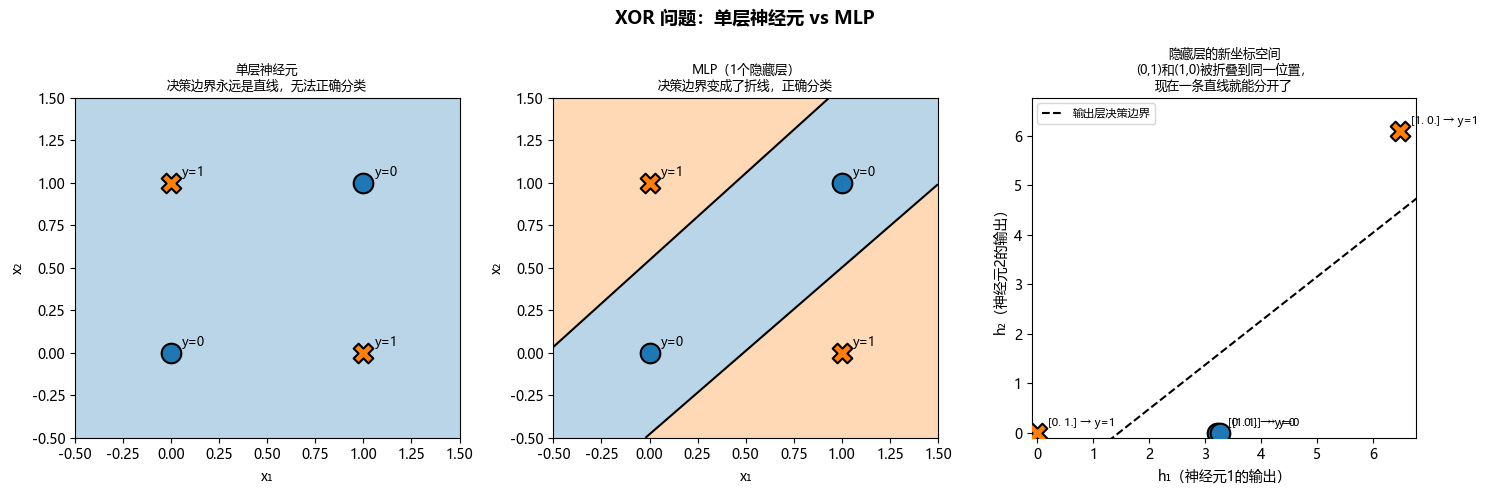


结论：
  单层：决策边界 = 一条直线，XOR 的对角分布天然无法被直线分开
  MLP ：隐藏层把原始空间'折叠'，(0,1)和(1,0)在新坐标里重叠为同一点
        输出层只需在新空间里画一条直线，映射回原始空间就变成了折线


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

# XOR 数据集：4 个点
X = torch.FloatTensor([[0, 0], [0, 1], [1, 0], [1, 1]])
y = torch.FloatTensor([0, 1, 1, 0])

# ── 演示 1：单层神经元无法学 XOR ──────────────────────────────
print("=== 单层神经元 vs XOR ===")

single_neuron = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)
opt = optim.Adam(single_neuron.parameters(), lr=0.1)
loss_fn = nn.BCELoss()

for _ in range(5000):
    opt.zero_grad()
    loss_fn(single_neuron(X).squeeze(), y).backward()
    opt.step()

with torch.no_grad():
    preds = single_neuron(X).squeeze().numpy()
labels = (preds > 0.5).astype(int)
print("单层神经元预测结果（训练 5000 轮）：")
for i, (xi, yi, pi, li) in enumerate(zip(X.numpy(), y.numpy(), preds, labels)):
    correct = "✓" if li == int(yi) else "✗"
    print(f"  x={xi}  真实={int(yi)}  预测概率={pi:.3f}  预测={li}  {correct}")
print(f"  准确率：{(labels == y.numpy().astype(int)).mean():.0%}  → 无论训练多久都无法全部正确")

# ── 演示 2：加一个隐藏层，轻松解决 ────────────────────────────
print("\n=== MLP（1个隐藏层，2个神经元）vs XOR ===")

mlp = nn.Sequential(
    nn.Linear(2, 2),   # 隐藏层：2 个神经元
    nn.ReLU(),
    nn.Linear(2, 1),   # 输出层
    nn.Sigmoid()
)
opt2 = optim.Adam(mlp.parameters(), lr=0.1)

for _ in range(5000):
    opt2.zero_grad()
    loss_fn(mlp(X).squeeze(), y).backward()
    opt2.step()

with torch.no_grad():
    preds2 = mlp(X).squeeze().numpy()
    hidden_repr = torch.relu(mlp[0](X)).numpy()  # 隐藏层输出（新坐标系）

labels2 = (preds2 > 0.5).astype(int)
print("MLP 预测结果（训练 5000 轮）：")
for i, (xi, yi, pi, li) in enumerate(zip(X.numpy(), y.numpy(), preds2, labels2)):
    correct = "✓" if li == int(yi) else "✗"
    print(f"  x={xi}  真实={int(yi)}  预测概率={pi:.3f}  预测={li}  {correct}")
print(f"  准确率：{(labels2 == y.numpy().astype(int)).mean():.0%}")

print("\n隐藏层将原始空间坐标变换到新坐标：")
print(f"  {'原始点':^12}  {'新坐标 (h1, h2)':^20}  标签")
for xi, hi, yi in zip(X.numpy(), hidden_repr, y.numpy()):
    print(f"  {str(xi):^12}  ({hi[0]:.3f}, {hi[1]:.3f})          {int(yi)}")

# ── 可视化：原始空间 vs 隐藏层新空间 ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('XOR 问题：单层神经元 vs MLP', fontsize=13, fontweight='bold')

colors = ['C0' if yi == 0 else 'C1' for yi in y.numpy()]
markers = ['o' if yi == 0 else 'X' for yi in y.numpy()]

# 图1：原始空间 + 单层神经元的决策边界
ax = axes[0]
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
with torch.no_grad():
    Z = single_neuron(grid).squeeze().numpy().reshape(xx.shape)
ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.3, colors=['C0', 'C1'])
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1.5)
for xi, c, m in zip(X.numpy(), colors, markers):
    ax.scatter(*xi, color=c, marker=m, s=200, zorder=5, edgecolors='black', linewidths=1.5)
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_title('单层神经元\n决策边界永远是直线，无法正确分类', fontsize=9)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
for xi, yi in zip(X.numpy(), y.numpy()):
    ax.annotate(f'y={int(yi)}', xi, textcoords='offset points', xytext=(8, 5), fontsize=9)

# 图2：原始空间 + MLP 的决策边界
ax = axes[1]
with torch.no_grad():
    Z2 = mlp(grid).squeeze().numpy().reshape(xx.shape)
ax.contourf(xx, yy, Z2, levels=[0, 0.5, 1], alpha=0.3, colors=['C0', 'C1'])
ax.contour(xx, yy, Z2, levels=[0.5], colors='black', linewidths=1.5)
for xi, c, m in zip(X.numpy(), colors, markers):
    ax.scatter(*xi, color=c, marker=m, s=200, zorder=5, edgecolors='black', linewidths=1.5)
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_title('MLP（1个隐藏层）\n决策边界变成了折线，正确分类', fontsize=9)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
for xi, yi in zip(X.numpy(), y.numpy()):
    ax.annotate(f'y={int(yi)}', xi, textcoords='offset points', xytext=(8, 5), fontsize=9)

# 图3：隐藏层新坐标系
ax = axes[2]
for hi, c, m, xi, yi in zip(hidden_repr, colors, markers, X.numpy(), y.numpy()):
    ax.scatter(*hi, color=c, marker=m, s=200, zorder=5, edgecolors='black', linewidths=1.5)
    ax.annotate(f'{xi} → y={int(yi)}', hi, textcoords='offset points', xytext=(8, 5), fontsize=8)

# 在新空间里画输出层的决策边界
w_out = mlp[2].weight.detach().numpy()[0]
b_out = mlp[2].bias.detach().numpy()[0]
if abs(w_out[1]) > 1e-6:
    h1_range = np.linspace(-0.1, max(hidden_repr[:, 0]) + 0.3, 100)
    h2_line = -(w_out[0] * h1_range + b_out) / w_out[1]
    ax.plot(h1_range, h2_line, 'k--', lw=1.5, label='输出层决策边界')
    ax.legend(fontsize=8)

h_max = hidden_repr.max() + 0.3
ax.set_xlim(-0.1, h_max); ax.set_ylim(-0.1, h_max)
ax.set_title('隐藏层的新坐标空间\n(0,1)和(1,0)被折叠到同一位置，\n现在一条直线就能分开了', fontsize=9)
ax.set_xlabel('h₁（神经元1的输出）')
ax.set_ylabel('h₂（神经元2的输出）')

plt.tight_layout()
plt.show()

print("\n结论：")
print("  单层：决策边界 = 一条直线，XOR 的对角分布天然无法被直线分开")
print("  MLP ：隐藏层把原始空间'折叠'，(0,1)和(1,0)在新坐标里重叠为同一点")
print("        输出层只需在新空间里画一条直线，映射回原始空间就变成了折线")

### 多层全连接神经网络能学什么？

XOR 是最极端的最小案例，但同样的道理适用于所有线性不可分问题——月牙形、同心圆、任意弯曲的分类边界，本质上都是隐藏层把空间折叠之后，在新空间里变成了线性可分。

下面用两个经典非线性数据集演示多层全连接神经网络相比逻辑回归的优势：
- **月牙形数据（make_moons）**：两类呈月牙形交错，线性模型只能得到直线边界
- **同心圆数据（make_circles）**：内圆 vs 外环，线性模型完全无能为力

用 PyTorch 构建一个最小网络：`输入(2维) → 隐藏层(16个神经元，ReLU) → 输出(1维，Sigmoid)`

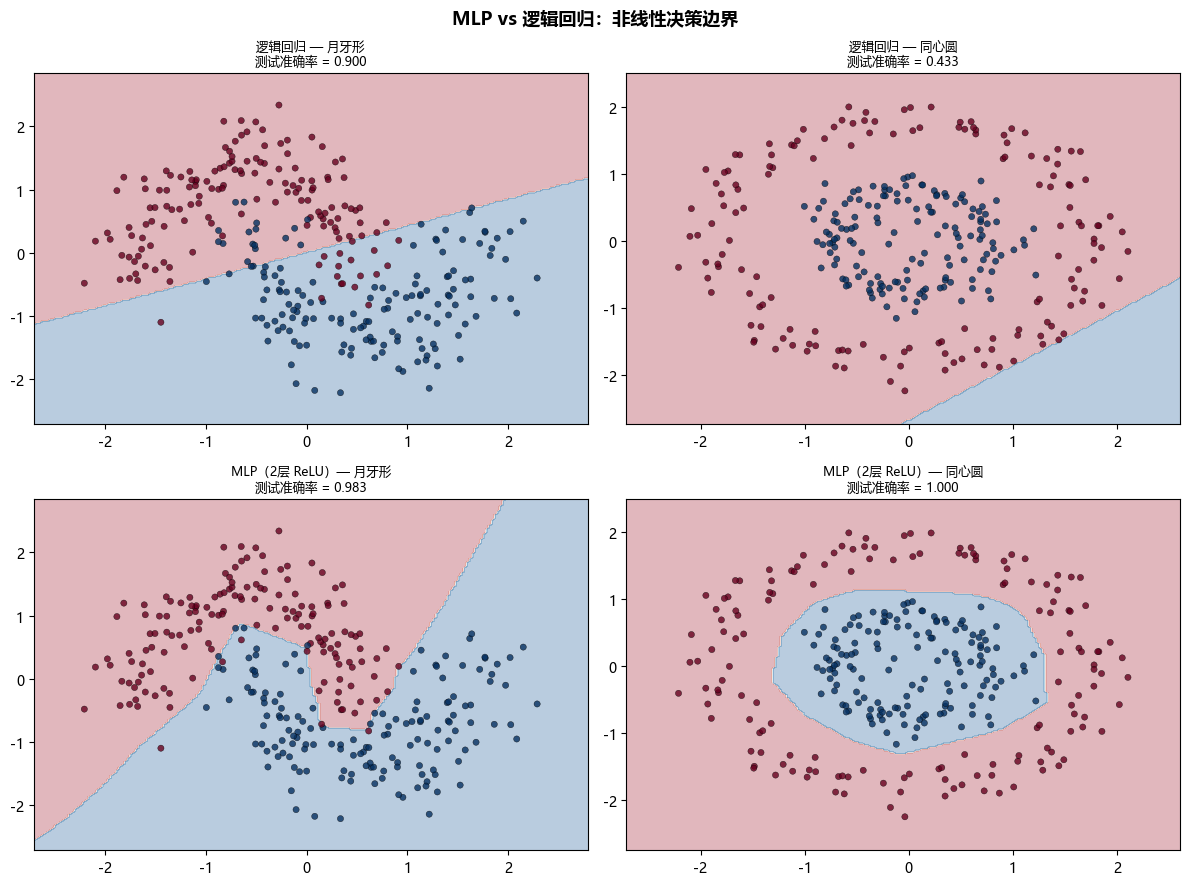

观察：
  逻辑回归的决策边界始终是直线（线性超平面）
  MLP 通过隐藏层 + ReLU 激活函数学到了弯曲的非线性边界
  关键：去掉 ReLU，MLP 的多层线性叠加仍等价于一个线性模型


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons, make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# ── 最小 MLP 定义 ──────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

def train_mlp(X_tr, y_tr, epochs=500, hidden=16, lr=0.01):
    model = MLP(hidden)
    opt   = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    X_t = torch.FloatTensor(X_tr)
    y_t = torch.FloatTensor(y_tr)
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        loss_fn(model(X_t), y_t).backward()
        opt.step()
    return model

def predict_mlp(model, X):
    model.eval()
    with torch.no_grad():
        return (model(torch.FloatTensor(X)).numpy() > 0.5).astype(int)

def plot_boundary(ax, model_fn, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model_fn(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', s=20, alpha=0.8, edgecolors='k', linewidths=0.3)
    ax.set_title(title, fontsize=9)

# ── 准备两个数据集 ─────────────────────────────────────────────
datasets = [
    ('月牙形', make_moons(n_samples=300, noise=0.2, random_state=42)),
    ('同心圆', make_circles(n_samples=300, noise=0.1, factor=0.4, random_state=42)),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('MLP vs 逻辑回归：非线性决策边界', fontsize=13, fontweight='bold')

for col, (name, (X, y)) in enumerate(datasets):
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

    # 逻辑回归
    lr_model = LogisticRegression().fit(X_tr, y_tr)
    lr_acc = accuracy_score(y_te, lr_model.predict(X_te))
    plot_boundary(axes[0][col],
                  lambda x, m=lr_model: m.predict(x),
                  X, y,
                  f'逻辑回归 — {name}\n测试准确率 = {lr_acc:.3f}')

    # MLP
    mlp = train_mlp(X_tr, y_tr)
    mlp_acc = accuracy_score(y_te, predict_mlp(mlp, X_te))
    plot_boundary(axes[1][col],
                  lambda x, m=mlp: predict_mlp(m, x),
                  X, y,
                  f'MLP（2层 ReLU）— {name}\n测试准确率 = {mlp_acc:.3f}')

plt.tight_layout()
plt.show()

print("观察：")
print("  逻辑回归的决策边界始终是直线（线性超平面）")
print("  MLP 通过隐藏层 + ReLU 激活函数学到了弯曲的非线性边界")
print("  关键：去掉 ReLU，MLP 的多层线性叠加仍等价于一个线性模型")

## 3.2 训练原理

### 前向传播（Forward Pass）

数据从输入层依次通过每一层，每层计算 $\mathbf{h} = f(W\mathbf{x} + \mathbf{b})$，最终得到预测值 $\hat{y}$。

**损失函数（Loss Function）** 衡量预测值与真实值的差距：
- 回归：均方误差 $\mathcal{L} = \frac{1}{n}\sum(y_i - \hat{y}_i)^2$
- 二分类：二元交叉熵 $\mathcal{L} = -\frac{1}{n}\sum[y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i)]$
- 多分类：交叉熵 $\mathcal{L} = -\frac{1}{n}\sum_i \sum_k y_{ik} \log \hat{y}_{ik}$

---

### 反向传播（Backpropagation）

反向传播是**自动微分（Automatic Differentiation）** 的一种实现，利用链式法则从输出层向输入层逐层计算梯度：

$$\frac{\partial \mathcal{L}}{\partial W_l} = \frac{\partial \mathcal{L}}{\partial \mathbf{h}_l} \cdot \frac{\partial \mathbf{h}_l}{\partial W_l}$$

**关键直觉**：不是直接计算「损失对每个权重的影响」，而是把梯度像水流一样从输出端往回传，每层只需知道「从我这里往后传来了多少梯度」以及「我这一层的局部导数」，两者相乘就得到本层权重的梯度。

PyTorch 通过构建**计算图（Computational Graph）** 自动完成这个过程：前向传播时记录所有操作，调用 `.backward()` 时沿图反向计算所有梯度。

---

### 梯度下降变体

得到梯度后，用梯度下降更新权重：

$$W \leftarrow W - \eta \cdot \frac{\partial \mathcal{L}}{\partial W}$$

其中 $\eta$ 是**学习率（Learning Rate）**，控制每步移动的距离。

| 优化器 | 核心思路 | 特点 |
|--------|----------|------|
| **SGD** | 随机取一个 batch 估计全局梯度 | 简单，需要仔细调学习率；可加动量（Momentum） |
| **AdaGrad** | 对频繁更新的参数降低学习率 | 稀疏特征好用；学习率单调递减，后期可能停止更新 |
| **RMSProp** | 梯度平方的指数移动平均，修复 AdaGrad 的递减问题 | LSTM 等循环网络常用 |
| **Adam** | 结合动量（一阶矩）+ RMSProp（二阶矩），自适应学习率 | **实践默认首选**，收敛快，对大多数问题效果好 |

**Batch 策略**：
- **Full-batch GD**：用全部数据计算梯度，准确但慢，内存占用大
- **SGD（随机梯度下降）**：每次只用 1 个样本，噪声大，但更新频繁
- **Mini-batch GD**：每次用一个小批量（32/64/128 个样本）——实践中最常用，在速度和准确性之间取得平衡

> **实践建议**：直接从 Adam + 学习率 1e-3 开始，没有明显问题就不要换优化器。

=== 前向传播 + 反向传播：手动追踪 ===

输入形状：torch.Size([8, 2])   标签形状：torch.Size([8])

前向传播完成
  预测值（前 4 个）: [0.7156 0.7318 0.6736 0.7171]
  真实标签（前 4 个）: [0 1 1 0]
  损失值 (BCE Loss): 1.0057

反向传播前，fc1.weight.grad: None
反向传播后，fc1.weight.grad 形状: torch.Size([4, 2])
  梯度样例（第1行）: [-0.06386  0.16075]
  → PyTorch 自动通过计算图反向计算了所有层的梯度

=== 优化器收敛速度对比 ===


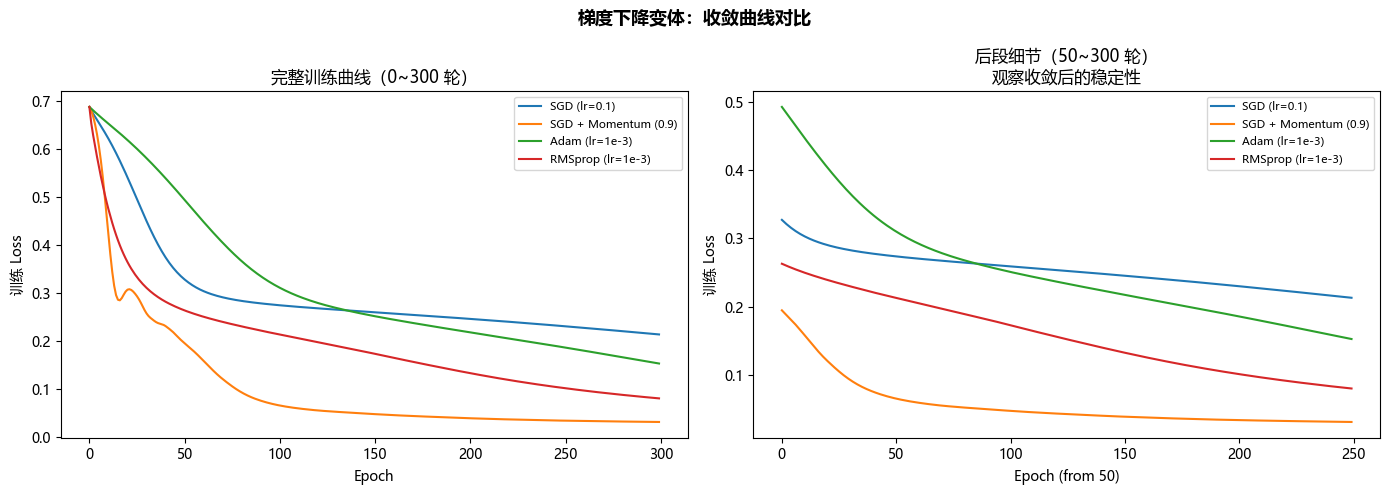


优化器最终 Loss（300 轮）：
  SGD (lr=0.1)                   0.2128
  SGD + Momentum (0.9)           0.0304
  Adam (lr=1e-3)                 0.1522
  RMSprop (lr=1e-3)              0.0796

观察：
  SGD 收敛最慢，需要较长时间才能稳定
  加上 Momentum 后 SGD 明显加速，惯性项帮助跨越小凹陷
  Adam 和 RMSprop 自适应学习率，前期收敛最快
  Adam 综合表现最好 → 实践中的默认首选


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

# ── 数据准备 ────────────────────────────────────────────────────
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X = StandardScaler().fit_transform(X)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

X_tr_t = torch.FloatTensor(X_tr)
y_tr_t  = torch.FloatTensor(y_tr)
X_te_t  = torch.FloatTensor(X_te)
y_te_t  = torch.FloatTensor(y_te)

# ── 演示 1：前向传播 + 反向传播手动追踪 ────────────────────────
print("=== 前向传播 + 反向传播：手动追踪 ===")
print()

class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 1)
    def forward(self, x):
        h = torch.relu(self.fc1(x))
        return torch.sigmoid(self.fc2(h)).squeeze()

net = TinyNet()
loss_fn = nn.BCELoss()

# 取一个 batch
xb = X_tr_t[:8]
yb = y_tr_t[:8]

print(f"输入形状：{xb.shape}   标签形状：{yb.shape}")

# 前向传播
pred = net(xb)
loss = loss_fn(pred, yb)
print(f"\n前向传播完成")
print(f"  预测值（前 4 个）: {pred.detach().numpy()[:4].round(4)}")
print(f"  真实标签（前 4 个）: {yb.numpy()[:4].astype(int)}")
print(f"  损失值 (BCE Loss): {loss.item():.4f}")

# 反向传播前，梯度为 None
print(f"\n反向传播前，fc1.weight.grad: {net.fc1.weight.grad}")

# 反向传播
loss.backward()
print(f"反向传播后，fc1.weight.grad 形状: {net.fc1.weight.grad.shape}")
print(f"  梯度样例（第1行）: {net.fc1.weight.grad[0].detach().numpy().round(5)}")
print(f"  → PyTorch 自动通过计算图反向计算了所有层的梯度")

# ── 演示 2：不同优化器的收敛曲线对比 ───────────────────────────
print("\n=== 优化器收敛速度对比 ===")

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze()

def run_optimizer(opt_cls, opt_kwargs, epochs=300):
    torch.manual_seed(0)
    model = Net()
    optimizer = opt_cls(model.parameters(), **opt_kwargs)
    loss_fn   = nn.BCELoss()
    losses = []
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(model(X_tr_t), y_tr_t)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

optimizer_configs = [
    ('SGD (lr=0.1)',           optim.SGD,     {'lr': 0.1}),
    ('SGD + Momentum (0.9)',   optim.SGD,     {'lr': 0.1, 'momentum': 0.9}),
    ('Adam (lr=1e-3)',         optim.Adam,    {'lr': 1e-3}),
    ('RMSprop (lr=1e-3)',      optim.RMSprop, {'lr': 1e-3}),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('梯度下降变体：收敛曲线对比', fontsize=13, fontweight='bold')

all_losses = {}
for name, cls, kwargs in optimizer_configs:
    losses = run_optimizer(cls, kwargs)
    all_losses[name] = losses
    axes[0].plot(losses, label=name, lw=1.5)
    axes[1].plot(losses[50:], label=name, lw=1.5)  # 放大后半段

axes[0].set_title('完整训练曲线（0~300 轮）')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('训练 Loss')
axes[0].legend(fontsize=8)

axes[1].set_title('后段细节（50~300 轮）\n观察收敛后的稳定性')
axes[1].set_xlabel('Epoch (from 50)')
axes[1].set_ylabel('训练 Loss')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n优化器最终 Loss（300 轮）：")
for name, losses in all_losses.items():
    print(f"  {name:<30} {losses[-1]:.4f}")
print()
print("观察：")
print("  SGD 收敛最慢，需要较长时间才能稳定")
print("  加上 Momentum 后 SGD 明显加速，惯性项帮助跨越小凹陷")
print("  Adam 和 RMSprop 自适应学习率，前期收敛最快")
print("  Adam 综合表现最好 → 实践中的默认首选")

## 3.3 正则化与调参

深度学习模型容量很大，在训练集上容易过拟合。正则化技术的目标是：**在不减少模型容量的前提下，降低模型对训练集噪声的记忆**。

---

### Dropout

训练时随机将部分神经元的输出置为 0（即「丢弃」），使网络不能依赖任何单一特征或神经元，被迫学习更鲁棒的表示。

```
训练时：每个神经元以概率 p 被丢弃 → 每次 forward 看到一个略不同的网络
预测时：所有神经元都保留，但输出乘以 (1-p) 保持期望值不变
```

**为什么有效？** 可以理解为训练了指数级数量的「瘦子网络」并做了隐式集成。

- `p=0.5`：隐藏层常用
- `p=0.1~0.3`：输入层或卷积层，丢弃率不宜过高
- 如果验证集 Loss 和训练集 Loss 差距大（过拟合），增大 dropout rate；如果模型欠拟合，减小或去掉 Dropout

---

### Batch Normalization（BatchNorm）

在每一层的激活值上做标准化：对当前 batch 内，把每个特征维度的输出归一化到均值 0、方差 1，然后用可学习的参数 $\gamma, \beta$ 恢复表达能力。

$$\hat{x} = \frac{x - \mu_{batch}}{\sqrt{\sigma^2_{batch} + \epsilon}} \qquad y = \gamma \hat{x} + \beta$$

**效果**：
- 大幅加速训练（允许使用更大的学习率）
- 减少对权重初始化的敏感性
- 有轻微正则化效果（batch 内的随机性引入噪声）

**放置位置**：通常放在线性层/卷积层之后、激活函数之前（`Linear → BN → ReLU`）。

> **注意**：BatchNorm 在训练和推理时行为不同——训练时用当前 batch 的统计量，推理时用训练阶段积累的移动平均。必须在推理时调用 `model.eval()`，否则统计量不对。

---

### 学习率调度（Learning Rate Scheduling）

固定学习率的问题：
- 太大：在极值附近震荡，无法收敛
- 太小：收敛过慢，容易陷入局部最优

解决方案：**从大到小动态调整学习率**。

| 调度策略 | 规律 | 适用场景 |
|---------|------|----------|
| **StepLR** | 每隔 N 轮乘以 γ（如 0.1）| 简单，可预测 |
| **CosineAnnealing** | 余弦曲线衰减，周期性 warm restart | 图像识别常用 |
| **ReduceLROnPlateau** | 验证集 Loss 停滞时自动降低 | 不确定何时衰减时首选 |
| **Warmup + Decay** | 先线性升温再衰减 | Transformer 标配 |

---

### 早停（Early Stopping）

训练时监控**验证集 Loss**，当验证 Loss 停止下降超过 N 轮（patience）时停止训练，保存此前验证 Loss 最低的模型。

```
          训练 Loss ↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓（一直在下降）
          验证 Loss ↓↓↓↓↓（开始上升）↑↑↑↑↑ ← 过拟合开始
                          ↑
                    最佳模型保存点
```

早停是**最简单也最有效**的防过拟合策略之一，可以和其他正则化方法叠加使用。

训练中...


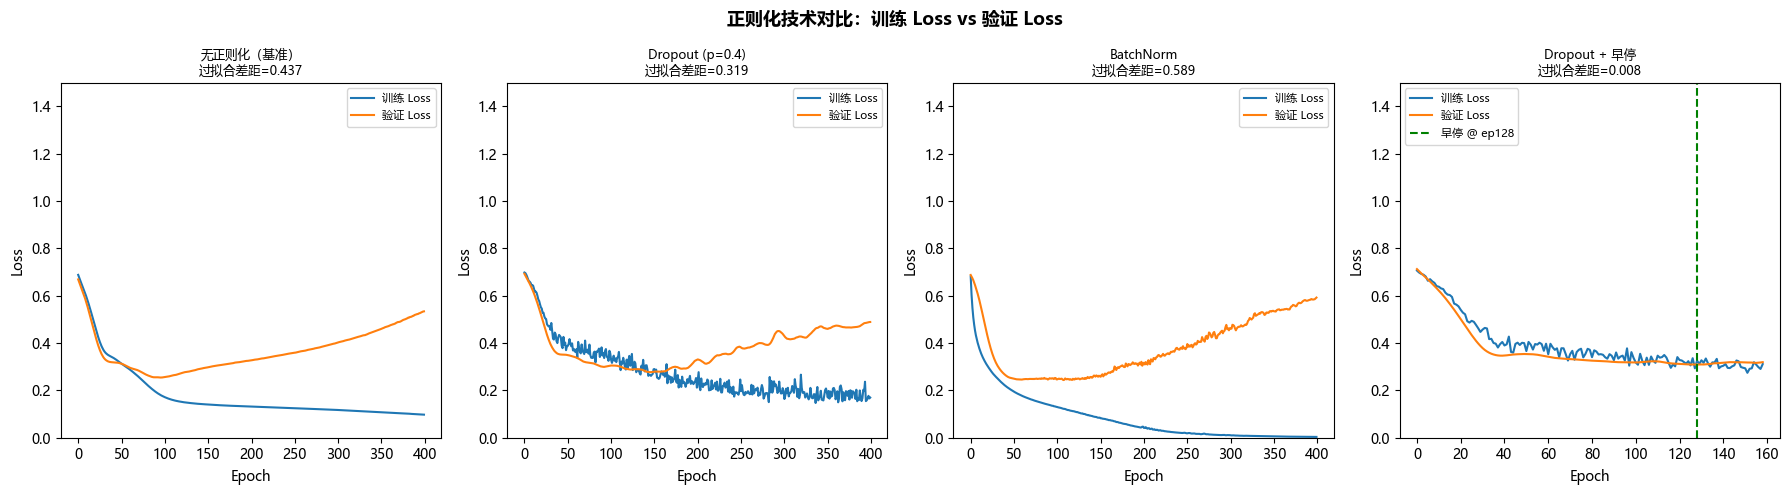


=== 学习率调度演示 ===


C:\Users\I552307\AppData\Local\Temp\claude\ipykernel_38644\4104983583.py:131: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()


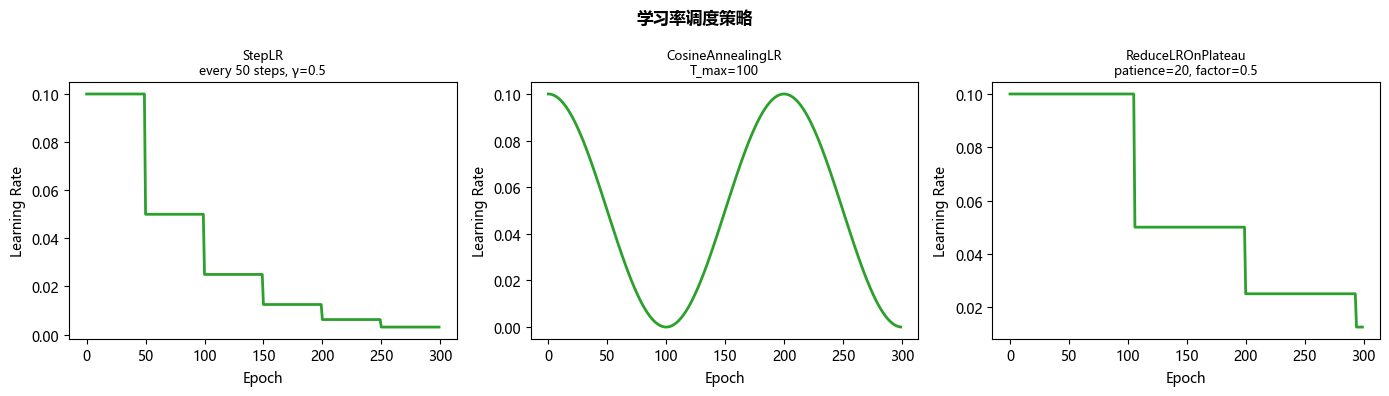


正则化技术总结：
  Dropout  ：训练时随机丢弃神经元，强迫网络学鲁棒表示，相当于隐式集成
  BatchNorm：归一化激活值，加速训练，减少初始化敏感性
  学习率调度：从大到小动态调整，既快速收敛又能精细调整到低 Loss
  早停     ：监控验证集 Loss，在过拟合发生前停止，最简单有效的方法

实践建议：先加 BatchNorm，再加 Dropout，最后用 ReduceLROnPlateau + 早停


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

# ── 数据（有意用小数据集，更容易展示过拟合）─────────────────
X, y = make_moons(n_samples=200, noise=0.3, random_state=42)
X = StandardScaler().fit_transform(X)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

to_t = lambda arr: torch.FloatTensor(arr)
X_tr_t,  y_tr_t  = to_t(X_tr),  to_t(y_tr)
X_val_t, y_val_t = to_t(X_val), to_t(y_val)

# ── 模型工厂：支持 Dropout 和 BatchNorm 开关 ──────────────────
def make_model(use_dropout=False, use_bn=False, p=0.5):
    layers = []
    dims = [2, 64, 64, 64, 1]
    for i in range(len(dims) - 1):
        layers.append(nn.Linear(dims[i], dims[i+1]))
        if i < len(dims) - 2:  # 非最后一层
            if use_bn:
                layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(nn.ReLU())
            if use_dropout:
                layers.append(nn.Dropout(p))
        else:
            layers.append(nn.Sigmoid())
    return nn.Sequential(*layers)

def train_and_record(model, epochs=300, lr=1e-3, patience=None):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.BCELoss()
    train_losses, val_losses = [], []
    best_val, best_ep, best_state = float('inf'), 0, None
    no_improve = 0

    for ep in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(model(X_tr_t).squeeze(), y_tr_t)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t).squeeze(), y_val_t).item()
        val_losses.append(val_loss)

        # 早停逻辑
        if patience is not None:
            if val_loss < best_val:
                best_val   = val_loss
                best_ep    = ep
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    break

    return train_losses, val_losses, best_ep

# ── 4 种配置对比 ───────────────────────────────────────────────
configs = [
    ('无正则化（基准）',   make_model(),                    False),
    ('Dropout (p=0.4)',    make_model(use_dropout=True, p=0.4), False),
    ('BatchNorm',          make_model(use_bn=True),         False),
    ('Dropout + 早停',     make_model(use_dropout=True, p=0.4), True),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('正则化技术对比：训练 Loss vs 验证 Loss', fontsize=13, fontweight='bold')

torch.manual_seed(0)
print("训练中...")
for i, (name, model, use_early_stop) in enumerate(configs):
    torch.manual_seed(0)
    patience_val = 30 if use_early_stop else None
    tr_l, val_l, best_ep = train_and_record(model, epochs=400, patience=patience_val)
    ax = axes[i]
    ax.plot(tr_l,  label='训练 Loss', color='C0', lw=1.5)
    ax.plot(val_l, label='验证 Loss', color='C1', lw=1.5)
    if use_early_stop:
        ax.axvline(best_ep, color='green', linestyle='--', lw=1.5, label=f'早停 @ ep{best_ep}')
    gap = val_l[-1] - tr_l[-1]
    ax.set_title(f'{name}\n过拟合差距={gap:.3f}', fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.5)

plt.tight_layout()
plt.show()

# ── 学习率调度演示 ──────────────────────────────────────────────
print("\n=== 学习率调度演示 ===")

fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))
fig2.suptitle('学习率调度策略', fontsize=12, fontweight='bold')

schedulers_cfg = [
    ('StepLR\nevery 50 steps, γ=0.5',
     lambda opt: optim.lr_scheduler.StepLR(opt, step_size=50, gamma=0.5)),
    ('CosineAnnealingLR\nT_max=100',
     lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=100)),
    ('ReduceLROnPlateau\npatience=20, factor=0.5',
     lambda opt: optim.lr_scheduler.ReduceLROnPlateau(opt, patience=20, factor=0.5)),
]

for ax, (title, sched_fn) in zip(axes2, schedulers_cfg):
    dummy_model = nn.Linear(1, 1)
    opt   = optim.SGD(dummy_model.parameters(), lr=0.1)
    sched = sched_fn(opt)
    lrs   = []
    # 模拟 300 轮，ReduceLROnPlateau 需要传入一个 metric
    fake_loss = np.linspace(1.0, 0.2, 300) + 0.05 * np.sin(np.linspace(0, 20, 300))
    for ep in range(300):
        lrs.append(opt.param_groups[0]['lr'])
        if isinstance(sched, optim.lr_scheduler.ReduceLROnPlateau):
            sched.step(fake_loss[ep])
        else:
            sched.step()
    ax.plot(lrs, color='C2', lw=2)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')

plt.tight_layout()
plt.show()

print("\n正则化技术总结：")
print("  Dropout  ：训练时随机丢弃神经元，强迫网络学鲁棒表示，相当于隐式集成")
print("  BatchNorm：归一化激活值，加速训练，减少初始化敏感性")
print("  学习率调度：从大到小动态调整，既快速收敛又能精细调整到低 Loss")
print("  早停     ：监控验证集 Loss，在过拟合发生前停止，最简单有效的方法")
print()
print("实践建议：先加 BatchNorm，再加 Dropout，最后用 ReduceLROnPlateau + 早停")